In [28]:
import tensorflow as tf
# TensorFlow: Used to build, train, and evaluate deep learning models.

import numpy as np
# NumPy: Used for numerical calculations and working with arrays/matrices.

import pandas as pd
# Pandas: Used for loading, cleaning, manipulating, and analyzing data.

from pylab import rcParams
# rcParams: Used to customize Matplotlib's default settings, such as figure size.

import matplotlib.pyplot as plt
# Matplotlib: Used to create graphs, plots, charts, and visualizations.

import warnings
# Warnings: Used to control/hide warning messages generated by Python or libraries.

from mlxtend.plotting import plot_decision_regions
# plot_decision_regions: Used to visualize the decision boundaries of a classification model.

from matplotlib.colors import ListedColormap
# ListedColormap: Used to create custom colors for plots and decision regions.

from tensorflow.keras.models import Sequential
# Sequential: Used to create a neural network layer-by-layer in sequence.

from tensorflow.keras.layers import Dropout
# Dropout: Helps prevent overfitting by randomly disabling some neurons during training.

from tensorflow.keras.layers import Dense
# Dense: Creates a fully connected neural network layer.

from tensorflow.keras.callbacks import EarlyStopping
# EarlyStopping: Stops training when the model stops improving, helping prevent overfitting.

from sklearn.model_selection import train_test_split
# train_test_split: Splits the dataset into training and testing/validation portions.

from sklearn.datasets import make_circles
# make_circles: Generates a synthetic dataset containing two circular classes.

import seaborn as sns
# Seaborn: Used for attractive and easier statistical/data visualizations.

In [29]:
X, y = make_circles(
    n_samples=100,      # Generate 100 data points
    noise=0.1,           # Add some random noise to the data
    random_state=1       # Keep the same dataset every time
)

<Axes: >

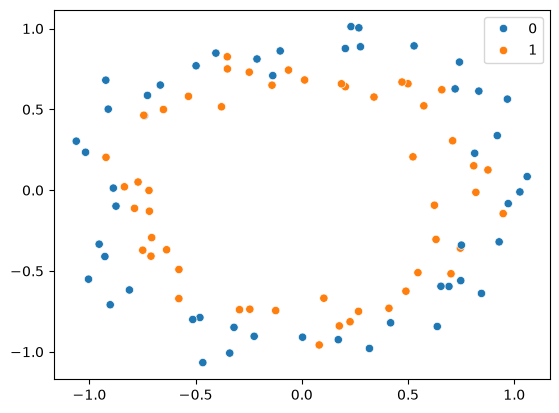

In [30]:
sns.scatterplot(
    x=X[:, 0],     # First feature → X-axis
    y=X[:, 1],     # Second feature → Y-axis
    hue=y          # Color points according to class (0/1)
)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [32]:
model = Sequential()

model.add(Dense(256,activation='relu', input_dim=2 ))
model.add(Dense(1, activation='sigmoid'))

e:\DL_by_CompusX\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.compile(
    loss='binary_crossentropy',  # How much wrong?
    optimizer='adam',            # How to improve?
    metrics=['accuracy']          # How accurate?
)

In [35]:
history = model.fit(
    X_train,                         # Training inputs
    y_train,                         # Training labels
    validation_data=(X_test,y_test), # Check performance on test data
    epochs=1500,                     # Train 1500 times
    verbose=0                        # Don't show training progress
)

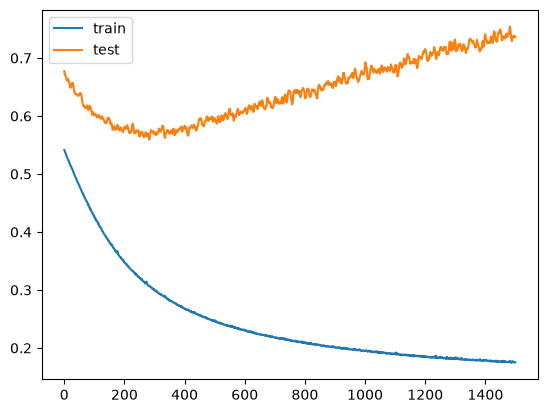

In [36]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

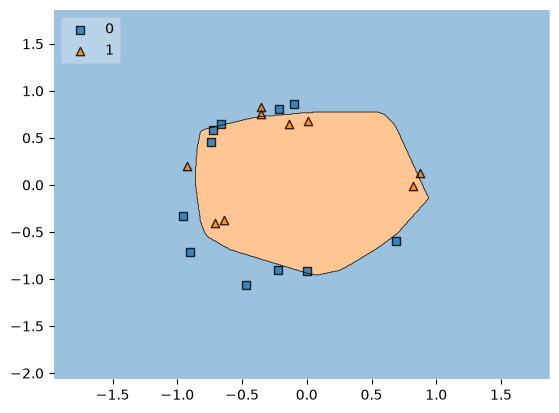

In [37]:
class MyModel:
    def predict(self, X):
        # Get predictions from the trained Keras model
        pred = model.predict(X, verbose=0)

        # Convert probabilities into class 0 or 1
        return (pred >= 0.5).astype(int).ravel()


clf = MyModel()

plot_decision_regions(
    X_test,              # Test input data
    y_test.ravel(),      # Test labels converted to 1D
    clf=clf,              # Our classifier
    legend=2              # Display legend
)

plt.show()               # Show the decision boundary

Early Stopping

In [38]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [39]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [42]:
callback = EarlyStopping(
    monitor="val_loss",              # Monitor validation loss
    min_delta=0.00001,               # Minimum improvement required
    patience=20,                     # Wait 20 epochs without improvement
    verbose=1,                       # Show stopping message
    mode="min",                      # Lower val_loss is better
    restore_best_weights=True        # Restore best weights
)

In [43]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5250 - loss: 0.6905 - val_accuracy: 0.3500 - val_loss: 0.7106
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5375 - loss: 0.6895 - val_accuracy: 0.3500 - val_loss: 0.7111
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5375 - loss: 0.6885 - val_accuracy: 0.3500 - val_loss: 0.7112
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5375 - loss: 0.6875 - val_accuracy: 0.3500 - val_loss: 0.7118
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5500 - loss: 0.6864 - val_accuracy: 0.3500 - val_loss: 0.7117
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5625 - loss: 0.6859 - val_accuracy: 0.4000 - val_loss: 0.7125
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5625 - loss: 0.6848 - val_accuracy: 0.4000 - val_loss: 0.7140
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5625 - loss: 0.6841 - val_accuracy: 0.4000 - val_loss: 0.71

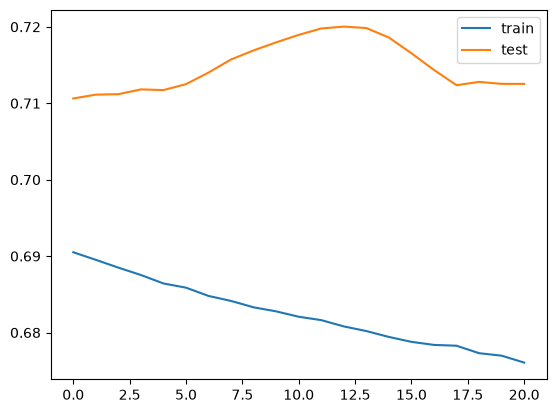

In [44]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 5s 535us/step


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

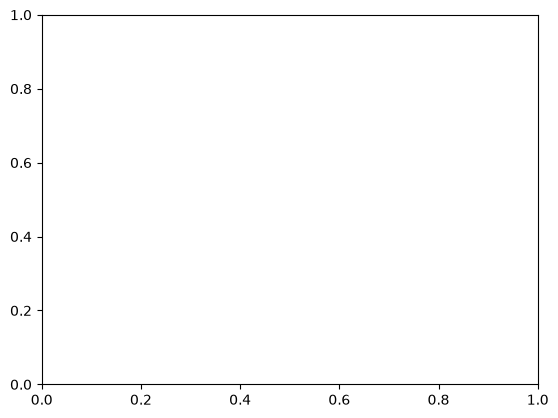

In [45]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()